### Assignment 8
* Kit Illick
* cei2119
* March 31, 2026

In [16]:
import pandas as pd
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})
df.tail()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN
716164,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 18:00:00,NR,24.2000,90.4000,NaN,NaN


In [2]:
#Importing relevant libraries
import numpy as np
from matplotlib import pyplot as plt

In [3]:
# Question 1
print('Unique BASIN values:')
print(df['BASIN'].unique())

print('\nUnique SUBBASIN values:')
print(df['SUBBASIN'].unique())

print('\nUnique NATURE values:')
print(df['NATURE'].unique())

Unique BASIN values:
['NI' 'SI' 'NA' 'EP' 'WP' 'SP' 'SA']

Unique SUBBASIN values:
['BB' 'AS' 'MM' 'GM' 'NA' 'CS' 'WA' 'EA' 'CP']

Unique NATURE values:
['NR' 'TS' 'ET' 'SS' 'MX' 'DS']


In [17]:
# Question 2
df = df.rename(columns={'WMO_WIND': 'WIND', 'WMO_PRES': 'PRES'})
df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
0,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 03:00:00,NR,10.9000,80.3000,NaN,NaN
1,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 06:00:00,NR,10.8709,79.8265,NaN,NaN
2,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 09:00:00,NR,10.8431,79.3524,NaN,NaN
3,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 12:00:00,NR,10.8188,78.8772,NaN,NaN
4,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 15:00:00,NR,10.8000,78.4000,NaN,NaN


In [5]:
# Question 3
df.nlargest(10, 'WIND')

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
666142,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3,-105.6,185.0,872.0
666140,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 06:00:00,TS,16.5,-105.4,180.0,886.0
666144,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 18:00:00,TS,18.3,-105.3,180.0,878.0
427655,1980214N11330,1980,57,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8,-86.4,165.0,899.0
178210,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 00:00:00,TS,24.6,-80.5,160.0,892.0
178211,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 02:00:00,TS,24.8,-80.8,160.0,892.0
178213,1935241N23291,1935,46,NA,GM,NaN,1935-09-03 06:00:00,TS,25.1,-81.1,160.0,NaN
482093,1988253N12306,1988,74,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7,-83.8,160.0,888.0
552477,1997253N12255,1997,81,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1,-109.6,160.0,902.0
605764,2005289N18282,2005,97,NA,CS,WILMA,2005-10-19 12:00:00,TS,17.3,-82.8,160.0,882.0


In [6]:
# Question 4
df.groupby('SID').WIND.max().nlargest(10)

SID
2015293N13266    185.0
1980214N11330    165.0
1935241N23291    160.0
1988253N12306    160.0
1997253N12255    160.0
2005289N18282    160.0
2019236N10314    160.0
1998295N12284    155.0
2005261N21290    155.0
2009288N07267    155.0
Name: WIND, dtype: float64

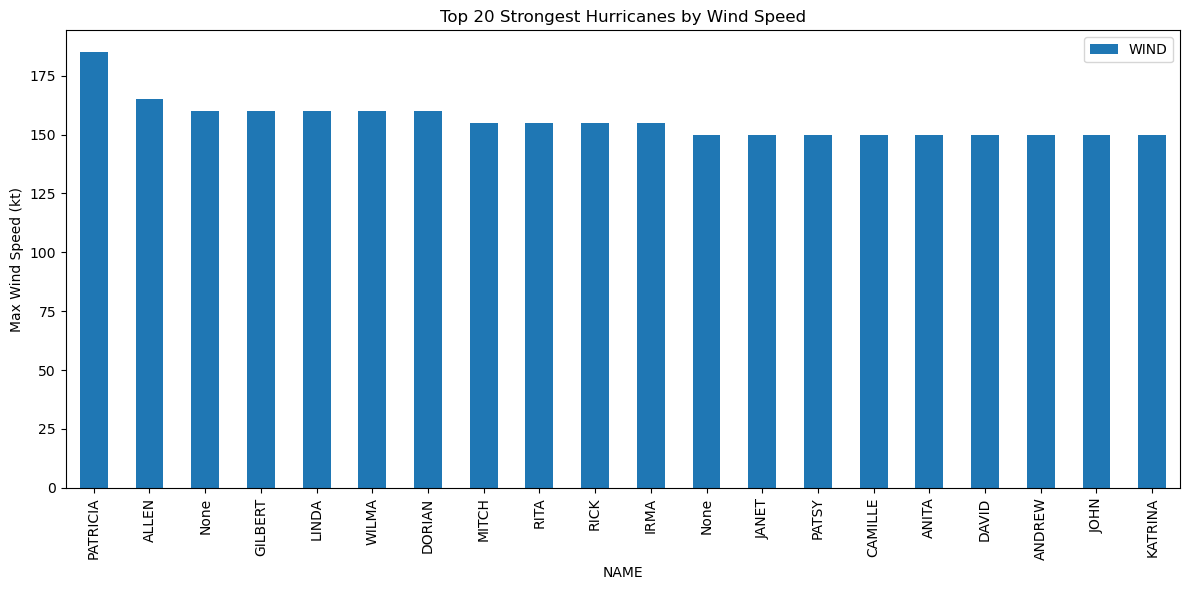

In [7]:
# Question 5
top20 = df.groupby('SID').agg({'WIND': 'max', 'NAME': 'first'}).nlargest(20, 'WIND')
top20.plot(kind='bar', x='NAME', y='WIND', figsize=(12, 6))
plt.ylabel('Max Wind Speed (kt)')
plt.title('Top 20 Strongest Hurricanes by Wind Speed')
plt.tight_layout()
plt.show()

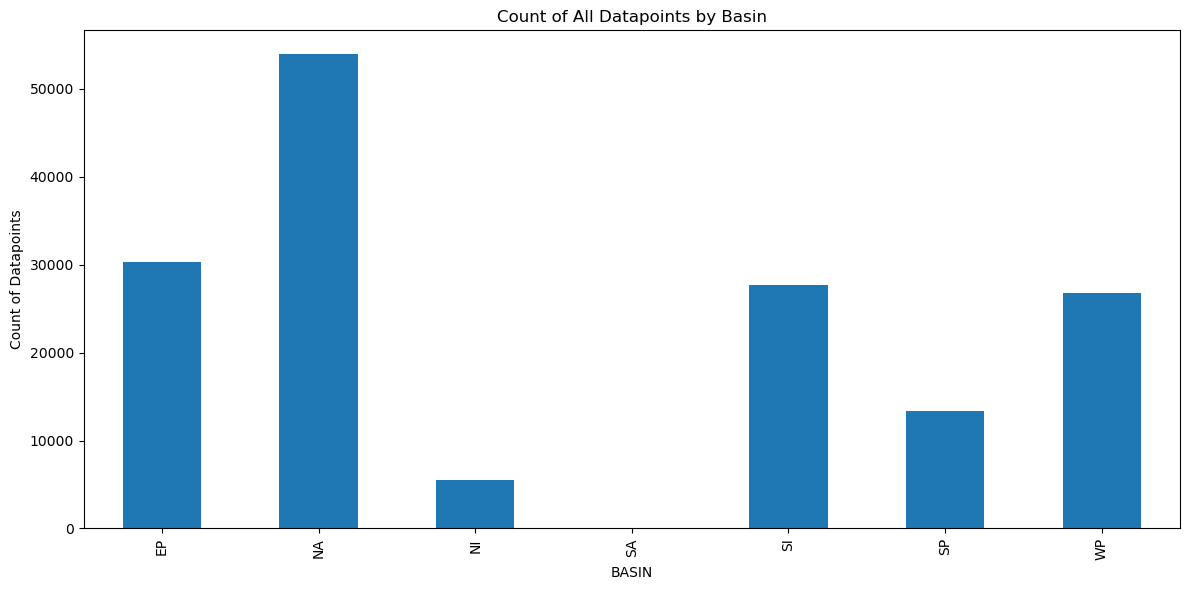

In [8]:
# Question 6
df.groupby('BASIN').WIND.count().plot(kind='bar', figsize=(12, 6))
plt.ylabel('Count of Datapoints')
plt.title('Count of All Datapoints by Basin')
plt.tight_layout()
plt.show()

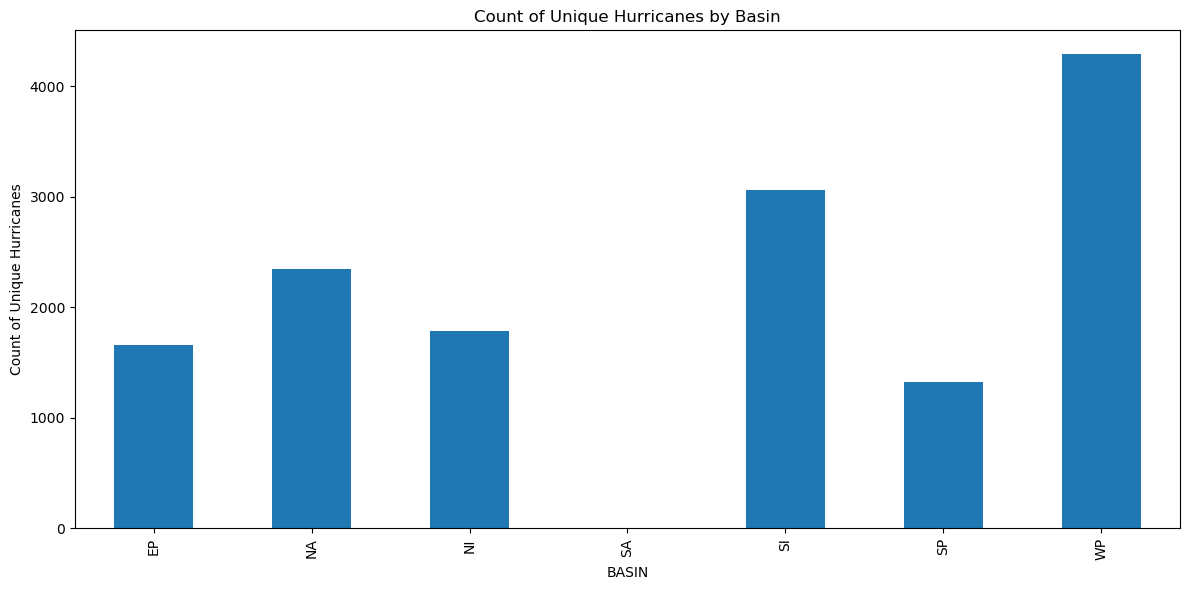

In [9]:
# Question 7
df.groupby('BASIN').SID.nunique().plot(kind='bar', figsize=(12, 6))
plt.ylabel('Count of Unique Hurricanes')
plt.title('Count of Unique Hurricanes by Basin')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Hexbin of Hurricane Datapoints')

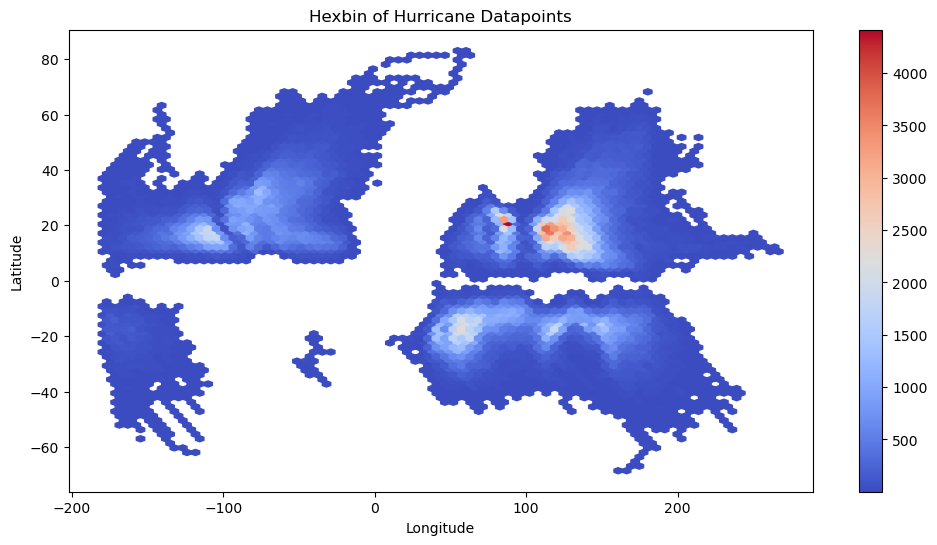

In [15]:
# Question 8
fig, ax = plt.subplots(figsize=(12, 6))
df.plot.hexbin(x='LON', y='LAT', gridsize=80, cmap='coolwarm', mincnt=1, ax=ax)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Hexbin of Hurricane Datapoints')

Katrina SID: ['2005236N23285']


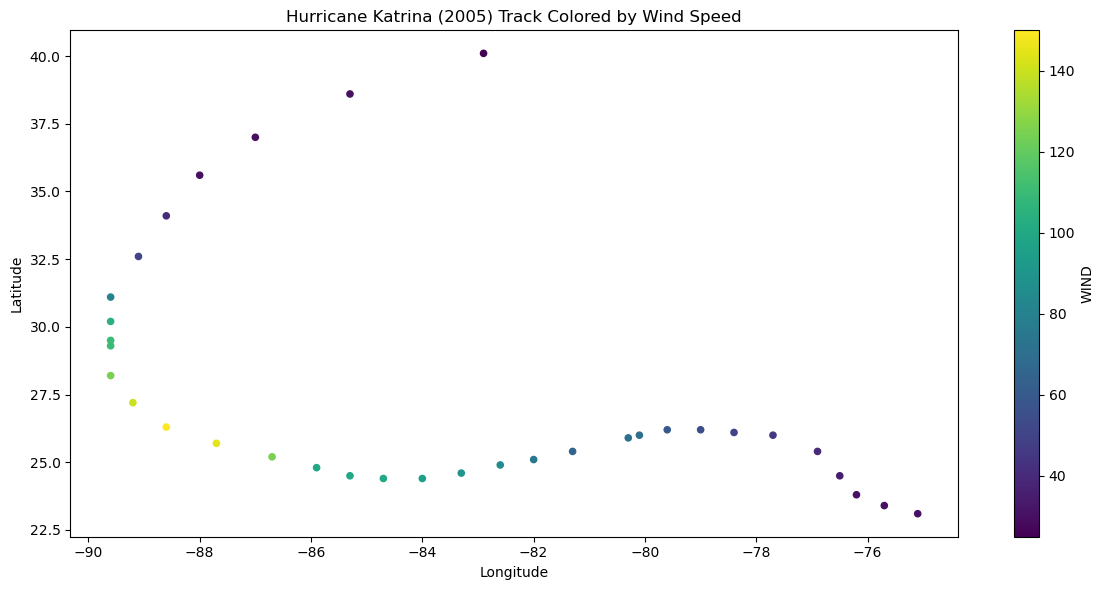

In [11]:
# Question 9
katrina_sid = df[(df['NAME'] == 'KATRINA') & (df['SEASON'] == 2005)]['SID'].unique()
print('Katrina SID:', katrina_sid)

katrina = df.groupby('SID').get_group(katrina_sid[0])
katrina.plot.scatter(x='LON', y='LAT', c='WIND', colormap='viridis', figsize=(12, 6))
plt.title('Hurricane Katrina (2005) Track Colored by Wind Speed')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

In [12]:
# Question 10
df = df.set_index('ISO_TIME')
df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,WIND,PRES
ISO_TIME,,,,,,,,,,,
1842-10-25 03:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.9000,80.3000,NaN,NaN
1842-10-25 06:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8709,79.8265,NaN,NaN
1842-10-25 09:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8431,79.3524,NaN,NaN
1842-10-25 12:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8188,78.8772,NaN,NaN
1842-10-25 15:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8000,78.4000,NaN,NaN


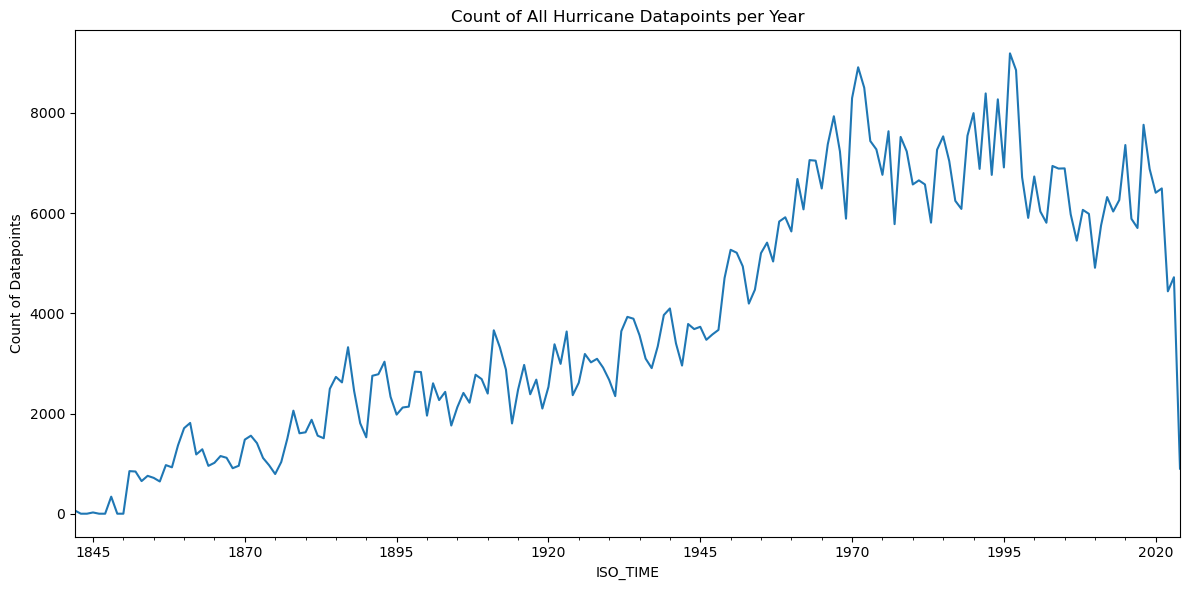

In [13]:
# Question 11
df.resample('YE').SID.count().plot(figsize=(12, 6))
plt.ylabel('Count of Datapoints')
plt.title('Count of All Hurricane Datapoints per Year')
plt.tight_layout()
plt.show()

Which years stand out as having anomalous hurricane activity?
1970 and 1995